**Loading the libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Dataset**

In [3]:
df = pd.read_csv("../Dataset/cleaned_lcs.csv")
df.head()

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic disease,fatigue,allergy,wheezing,alcohol consuming,coughing,shortness of breath,swallowing difficulty,chest pain,lung_cancer
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


**Inspecting Numerical Independent Feature**

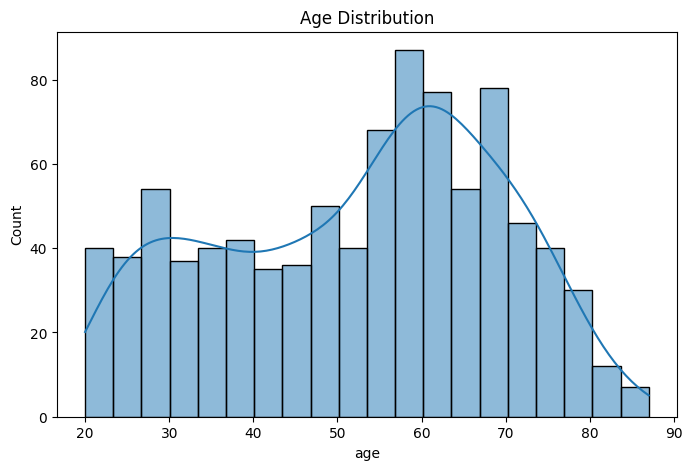

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

Histogram shows more concentrated around 60 and 70, which is a realistic scenario when it comes to cancer. The younger ones are unlikely to suffer, especially from lung cancer and there is less chance that it will show up in later age. The histogram shows a realistic real-world case.

**Chi-square Test**

In [5]:
from sklearn.feature_selection import chi2

K = df.drop('lung_cancer', axis=1)
m = df['lung_cancer']

chi_scores, p_values = chi2(K, m)

chi_df = pd.DataFrame({
    'Feature': K.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by='p-value')

chi_df

,Feature,Chi2 Score,p-value
13,swallowing difficulty,271.509968,5.318898e-61
14,chest pain,269.030250,1.846135e-60
12,shortness of breath,256.085311,1.224191e-57
2,smoking,241.043117,2.329494e-54
1,age,179.307333,6.865293e-41
11,coughing,74.752686,5.335314e-18
7,fatigue,67.027287,2.677749e-16
9,wheezing,12.957925,3.185701e-04
3,yellow_fingers,12.556734,3.947812e-04
10,alcohol consuming,10.392954,1.264971e-03


**Important Predictors**

swallowing difficulty, chest pain, shortness of breathe, smoking, age, coughing, fatigue

**Moderate Predictors**

wheezng, yellow fingers, alcohol consuming, chronic disease

**Insignificant Predictors**

allergy, anxiety, gender

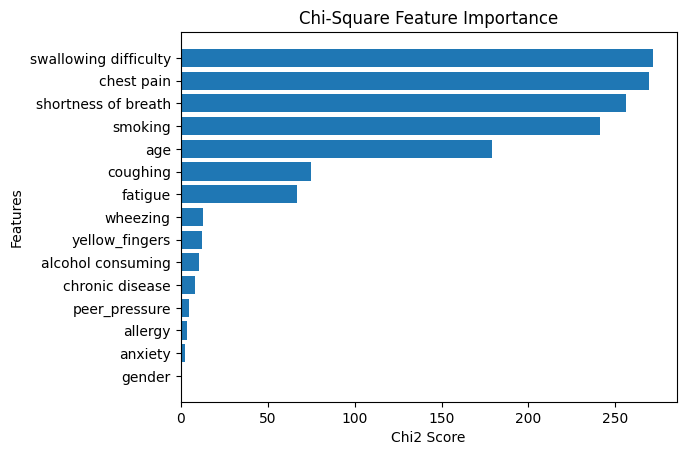

In [6]:
#visualizing the chi-square test

plt.figure()
plt.barh(chi_df['Feature'], chi_df['Chi2 Score'])
plt.title("Chi-Square Feature Importance")
plt.xlabel("Chi2 Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

Strong associations were observed between lung cancer and clinical symptoms such as chest pain, shortness of breath, swallowing difficulty, and smoking. These features stand out as key predictors and are expected to significantly influence the accuracy of any predictive model.

Moderate relationships were found for features like coughing and fatigue, indicating they may provide additional predictive support but are less central compared to the primary symptoms.

Weaker and minimal associations were observed for features such as age, wheezing, yellow fingers, alcohol consumption, chronic disease, peer pressure, allergy, and anxiety. While these variables might still have some effect, their direct relationship with lung cancer is limited.

Gender showed no meaningful correlation, suggesting it does not play a significant role in distinguishing lung cancer cases within this dataset.

**Logistic Regression Analysis with Stats Model**

In [11]:
import statsmodels.api as sm
#preparing data for logistic regression

X = df.drop(columns=['lung_cancer'])
y = df['lung_cancer']

#adding constant
X = sm.add_constant(X)

#fitting model
model = sm.Logit(y, X).fit()

# print model summary
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.214789
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:            lung_cancer   No. Observations:                  911
Model:                          Logit   Df Residuals:                      895
Method:                           MLE   Df Model:                           15
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.6898
Time:                        19:21:29   Log-Likelihood:                -195.67
converged:                       True   LL-Null:                       -630.71
Covariance Type:            nonrobust   LLR p-value:                8.961e-176
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -5.9425      0.773     -7.691      0.000      -7.457      -4

**Following features have p-value more than 0.05**
1. peer_pressure
2. gender
3. age
4. yellow_fingers
5. chronic disease
6. fatigue

This features will be dropped by a process of backward elimination.